In [1]:
%matplotlib inline
import sys, os
print("Python:", sys.executable)
print("JAVA_HOME:", os.environ.get("JAVA_HOME"))
print("SPARK_HOME:", os.environ.get("SPARK_HOME"))
os.environ["SPARK_LOCAL_IP"] = "127.0.0.1"

Python: /usr/bin/python3
JAVA_HOME: /usr/lib/jvm/java-11-openjdk-amd64
SPARK_HOME: /opt/spark


In [43]:
from pyspark.sql import SparkSession
import matplotlib.pyplot as plt
import numpy as np
from pyspark.sql import functions as F
import time
from pyspark.storagelevel import StorageLevel
import pandas as pd

spark = SparkSession.builder.getOrCreate()
sc = spark.sparkContext

PATH_MACHINE_EVENTS = "../spark-data/machine_events/*.csv.gz"
PATH_JOB_EVENTS  = "../spark-data/job_events/*.csv.gz"
PATH_TASK_EVENTS = "../spark-data/task_events/*.csv.gz"
PATH_TASK_USAGE = "../spark-data/task_usage/*.csv.gz"

In [3]:
print("Spark version :", spark.version)
print("spark.master  :", sc.master)
print("Java version  :", sc._jvm.java.lang.System.getProperty("java.version"))
print("Java vendor   :", sc._jvm.java.lang.System.getProperty("java.vendor"))

Spark version : 3.5.0
spark.master  : local[*]
Java version  : 11.0.29
Java vendor   : Ubuntu


In [4]:
# ----------------------------
# Parsing utilities
# ----------------------------
def to_int(x):
    return int(x) if x not in (None, "", "NULL") else None

def to_long(x):
    return int(x) if x not in (None, "", "NULL") else None

def to_float(x):
    return float(x) if x not in (None, "", "NULL") else None

## Q3 : Maintenance rate vs machine CPU class

**Metric / definition.**
- We interpret maintenance as machine unavailability periods.
- For each machine, a downtime interval starts at `REMOVE` and ends at the next `ADD`.
- Maintenance rate per machine = `downtime_fraction = total_downtime / trace_duration`.
- Machines are grouped into CPU bins of width 0.1: `[0.0,0.1), ..., [0.9,1.0]`.

**Method (Spark RDD).**
1. Parse `machine_events` into `(machine_id, (ts, event_type, cpu))`.
2. Compute trace duration from min/max timestamps (≈ 29 days).
3. For each machine: sort events by time and sum downtime over `REMOVE → ADD` pairs.
4. Join downtime with machine CPU capacity (taken from earliest ADD event when available).
5. Aggregate downtime statistics by CPU bin.

In [5]:
# ----------------------------
# Parsing machine events
# ----------------------------
def parse_machine_event(line):
    parts = line.split(",")
    # Defensive: some lines may be malformed
    if len(parts) < 6:
        return None
    
    ts = to_long(parts[0])
    mid = to_long(parts[1])
    et = to_int(parts[2])
    cpu = to_float(parts[4])
    mem = to_float(parts[5])
    
    if ts is None or mid is None or et is None:
        return None
    
    return (mid, (ts, et, cpu, mem))

In [6]:
# ----------------------------
# Load RDD
# ----------------------------
raw = sc.textFile(PATH_MACHINE_EVENTS)
machine_events = raw.map(parse_machine_event).filter(lambda x: x is not None).cache()

In [7]:
# Exploring the dataset: machine_events
print("\n" + "="*80)
print("Exploring the dataset: machine_events")
print(f"Number of records: {raw.count()}")
print("First record:")
print(raw.first())
print(f"Type of elements: {type(raw.first())}")


Exploring the dataset: machine_events


Number of records: 37780
First record:
0,5,0,HofLGzk1Or/8Ildj2+Lqv0UGGvY82NLoni8+J/Yy0RU=,0.5,0.2493
Type of elements: <class 'str'>


In [8]:
# ----------------------------
# Compute trace boundaries
# ----------------------------
timestamps = machine_events.map(lambda x: x[1][0])
trace_start = timestamps.min()
trace_end = timestamps.max()
trace_duration = trace_end - trace_start

print("Trace start (us):", trace_start)
print("Trace end   (us):", trace_end)
print("Trace duration (us):", trace_duration)

Trace start (us): 0
Trace end   (us): 2506135493517
Trace duration (us): 2506135493517


In [9]:
# ----------------------------
# CPU capacity per machine
# We take CPU from the earliest ADD event (event_type==0).
# ----------------------------
adds_cpu = (
    machine_events
    .filter(lambda x: x[1][1] == 0 and x[1][2] is not None)           
    .map(lambda x: (x[0], (x[1][0], x[1][2])))                       
    .reduceByKey(lambda a, b: a if a[0] < b[0] else b)
    .mapValues(lambda t: t[1])
)

fallback_cpu = (
    machine_events
    .filter(lambda x: x[1][2] is not None)
    .map(lambda x: (x[0], (x[1][0], x[1][2])))
    .reduceByKey(lambda a, b: a if a[0] < b[0] else b)
    .mapValues(lambda t: t[1])
)

cpu_by_machine = adds_cpu.union(fallback_cpu).reduceByKey(lambda a, b: a)  # prefer ADD when present
cpu_by_machine = cpu_by_machine.cache()

In [10]:
# ----------------------------
# Downtime per machine from REMOVE -> next ADD
# Count maintenance cycles
# ----------------------------
def compute_downtime_and_cycles(events_iter):
    events = sorted(events_iter, key=lambda e: e[0])
    offline_start = None
    downtime = 0
    cycles = 0
    
    for (ts, et, cpu, mem) in events:
        if et == 1:  # REMOVE
            if offline_start is None:
                offline_start = ts
        elif et == 0:  # ADD
            if offline_start is not None:
                downtime += (ts - offline_start)
                cycles += 1
                offline_start = None
    
    # If machine is removed but not added back within trace, ignore open interval
    return downtime, cycles

downtime_and_cycles = (
    machine_events
    .mapValues(lambda x: (x[0], x[1], x[2], x[3]))
    .groupByKey()
    .mapValues(compute_downtime_and_cycles)          # (mid, (downtime_us, cycles))
    .cache()
)

# Convert to downtime fraction (maintenance rate)
maintenance_rate = downtime_and_cycles.mapValues(
    lambda dc: (dc[0] / trace_duration if trace_duration > 0 else 0.0, dc[1])
)
# (mid, (downtime_fraction, cycles))

In [11]:
# ----------------------------
# Join with CPU and bin by CPU class
# ----------------------------
def cpu_bin_label(cpu, step=0.1):
    if cpu is None:
        return None
    # handle cpu == 1.0: force into last bin
    if cpu >= 1.0:
        lo = 1.0 - step
        hi = 1.0
    else:
        idx = int(cpu / step)
        lo = idx * step
        hi = lo + step
    return f"[{lo:.1f},{hi:.1f})"

joined = maintenance_rate.join(cpu_by_machine)
# (mid, ((downtime_fraction, cycles), cpu))

by_bin = (
    joined
    .map(lambda x: (cpu_bin_label(x[1][1], 0.1), (x[1][0][0], x[1][0][1], 1)))  # (bin, (downtime_frac, cycles, 1))
    .filter(lambda x: x[0] is not None)
)

# Aggregate per bin: sum downtime_frac, sum cycles, count
bin_stats = (
    by_bin
    .reduceByKey(lambda a, b: (a[0] + b[0], a[1] + b[1], a[2] + b[2]))
    .mapValues(lambda s: {
        "avg_downtime_frac": s[0] / s[2],
        "avg_cycles": s[1] / s[2],
        "count": s[2]
    })
    .collect()
)

# Sort bins in numeric order
def bin_key(lbl):
    lo = float(lbl.split(",")[0].replace("[",""))
    return lo

bin_stats = sorted(bin_stats, key=lambda x: bin_key(x[0]))

# Display result table
for b, stats in bin_stats:
    print(b, stats)

[0.2,0.3) {'avg_downtime_frac': 0.010790875814181955, 'avg_cycles': 0.8015873015873016, 'count': 126}
[0.5,0.6) {'avg_downtime_frac': 0.00499021270703738, 'avg_cycles': 0.6982588558195385, 'count': 11659}
[0.9,1.0) {'avg_downtime_frac': 0.003258560550834963, 'avg_cycles': 0.7744360902255639, 'count': 798}


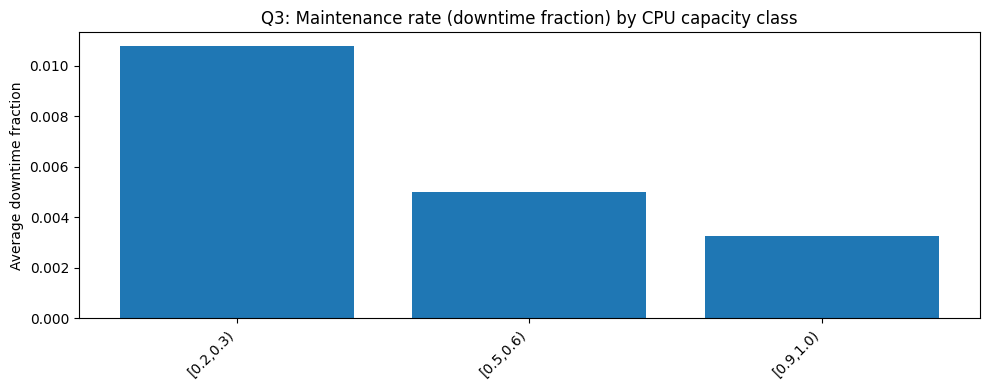

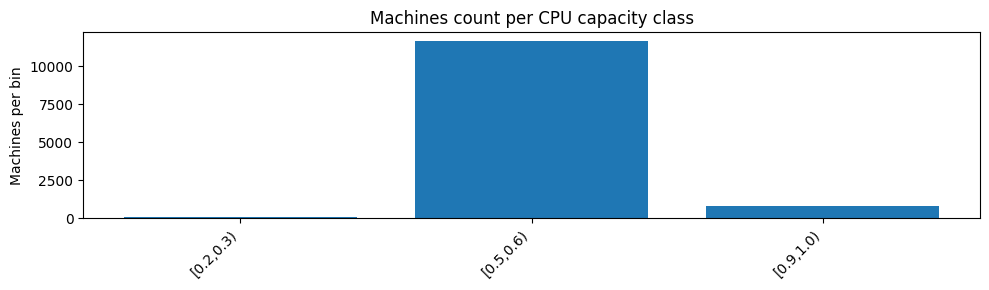

In [12]:
# Plot: average downtime fraction per CPU bin
bins = [b for b, _ in bin_stats]
avg_down = [stats["avg_downtime_frac"] for _, stats in bin_stats]
counts = [stats["count"] for _, stats in bin_stats]

plt.figure(figsize=(10, 4))
plt.bar(bins, avg_down)
plt.xticks(rotation=45, ha="right")
plt.ylabel("Average downtime fraction")
plt.title("Q3: Maintenance rate (downtime fraction) by CPU capacity class")
plt.tight_layout()
plt.savefig("../figures/q3_downtime_by_cpu_bin.png", dpi=300, bbox_inches="tight")
plt.show()

# Show counts to ensure bins aren't too sparse
plt.figure(figsize=(10, 3))
plt.bar(bins, counts)
plt.xticks(rotation=45, ha="right")
plt.ylabel("Machines per bin")
plt.title("Machines count per CPU capacity class")
plt.tight_layout()
plt.savefig("../figures/q3_machines_count_by_cpu_bin.png", dpi=300, bbox_inches="tight")
plt.show()

**Results.**

| CPU bin | #machines | avg downtime fraction | avg downtime (%) | avg maintenance cycles |
|---|---:|---:|---:|---:|
| [0.2,0.3) | 126 | 0.01079 | **1.079%** | 0.802 |
| [0.5,0.6) | 11,659 | 0.00499 | 0.499% | 0.698 |
| [0.9,1.0) | 798 | 0.00326 | 0.326% | 0.774 |

**Interpretation.**
A CPU class that stands out is **[0.2, 0.3)**, with an average downtime fraction of **~1.08%**, which is about **2.16×**  higher than the large [0.5, 0.6) class (**~0.50%**) and about **3.3×** higher than the [0.9, 1.0) class (~0.33%).

However, this result must be interpreted carefully because the [0.2, 0.3) class contains only **126 machines**, while [0.5, 0.6) contains **11,659 machines** (dominant population). This means the high maintenance rate for the low-CPU class could be influenced by:
- a small sample size (higher variance / sensitivity to outliers),
- a specific subgroup of machines (e.g., older / less reliable hardware pool),
- operational policies (low-capacity machines being used differently or more frequently taken out for maintenance).

## Q5 : Percentage of jobs/tasks killed or evicted: is it important?

**Metric.**
For jobs and tasks separately:
- `% killed = (# distinct entities with ≥1 KILL) / (total # distinct entities)`
- `% evicted = (# distinct entities with ≥1 EVICT) / (total # distinct entities)`
- `% killed-or-evicted = (# distinct entities with ≥1 {KILL or EVICT}) / total`

We count each entity once even if multiple events occur.

**Method (Spark RDD).**
1. Parse job_events → `(job_id, event_type)` and count distinct jobs.
2. Parse task_events → `((job_id, task_index), event_type)` and count distinct tasks.
3. Count distinct jobs/tasks that appear with `event_type in {EVICT=2, KILL=5}`.
4. Compute percentages and validate event availability in the subset.

In [13]:
# ----------------------------
# event_type codes
# ----------------------------
EVICT = 2
KILL  = 5

# ----------------------------
# Parsing job events
# ----------------------------

def parse_job_event(line):
    p = line.split(",")
    if len(p) < 4:
        return None
    ts = to_long(p[0])
    job_id = to_long(p[2])
    et = to_int(p[3])
    if ts is None or job_id is None or et is None:
        return None
    return (job_id, et)

def parse_task_event(line):
    p = line.split(",")
    if len(p) < 6:
        return None
    ts = to_long(p[0])
    job_id = to_long(p[2])
    task_index = to_int(p[3])
    et = to_int(p[5])
    if ts is None or job_id is None or task_index is None or et is None:
        return None
    return ((job_id, task_index), et)

In [14]:
# ----------------------------
# Load
# ----------------------------
job_events = sc.textFile(PATH_JOB_EVENTS).map(parse_job_event).filter(lambda x: x is not None).cache()
task_events = sc.textFile(PATH_TASK_EVENTS).map(parse_task_event).filter(lambda x: x is not None).cache()

In [15]:
# ----------------------------
# Totals
# ----------------------------
total_jobs = job_events.map(lambda x: x[0]).distinct().count()
total_tasks = task_events.map(lambda x: x[0]).distinct().count()

print("Total distinct jobs :", total_jobs)
print("Total distinct tasks:", total_tasks)

[Stage 12:==============================================>           (4 + 1) / 5]

Total distinct jobs : 6551
Total distinct tasks: 246415


In [16]:
# ----------------------------
# Jobs: killed/evicted
# ----------------------------
jobs_evicted = job_events.filter(lambda x: x[1] == EVICT).map(lambda x: x[0]).distinct().count()
jobs_killed  = job_events.filter(lambda x: x[1] == KILL ).map(lambda x: x[0]).distinct().count()

jobs_killed_or_evicted = (
    job_events
    .filter(lambda x: x[1] in (EVICT, KILL))
    .map(lambda x: x[0])
    .distinct()
    .count()
)

# ----------------------------
# Tasks: killed/evicted
# ----------------------------
tasks_evicted = task_events.filter(lambda x: x[1] == EVICT).map(lambda x: x[0]).distinct().count()
tasks_killed  = task_events.filter(lambda x: x[1] == KILL ).map(lambda x: x[0]).distinct().count()

tasks_killed_or_evicted = (
    task_events
    .filter(lambda x: x[1] in (EVICT, KILL))
    .map(lambda x: x[0])
    .distinct()
    .count()
)

# ----------------------------
# Percentages
# ----------------------------
def pct(part, whole):
    return (100.0 * part / whole) if whole else 0.0

In [17]:
print("\n--- JOBS ---")
print(f"Evicted: {jobs_evicted} ({pct(jobs_evicted, total_jobs):.3f}%)")
print(f"Killed : {jobs_killed} ({pct(jobs_killed, total_jobs):.3f}%)")
print(f"Killed or Evicted: {jobs_killed_or_evicted} ({pct(jobs_killed_or_evicted, total_jobs):.3f}%)")

print("\n--- TASKS ---")
print(f"Evicted: {tasks_evicted} ({pct(tasks_evicted, total_tasks):.3f}%)")
print(f"Killed : {tasks_killed} ({pct(tasks_killed, total_tasks):.3f}%)")
print(f"Killed or Evicted: {tasks_killed_or_evicted} ({pct(tasks_killed_or_evicted, total_tasks):.3f}%)")


--- JOBS ---
Evicted: 0 (0.000%)
Killed : 2465 (37.628%)
Killed or Evicted: 2465 (37.628%)

--- TASKS ---
Evicted: 24090 (9.776%)
Killed : 59078 (23.975%)
Killed or Evicted: 77862 (31.598%)


In [18]:
# Validatio check : What job event_types exist in your subset?
job_event_type_counts = (
    job_events
    .map(lambda x: (x[1], 1))
    .reduceByKey(lambda a,b: a+b)
    .collect()
)

for et, cnt in sorted(job_event_type_counts):
    print(et, cnt)

0 6255
1 6254
3 85
4 3671
5 2465
6 1


In [19]:
# Count how many eviction events per task
task_evict_counts = (
    task_events
    .filter(lambda x: x[1] == EVICT)
    .map(lambda x: (x[0], 1))
    .reduceByKey(lambda a,b: a+b)
)

# Simple stats: min / mean / max of eviction counts per evicted task
evict_vals = task_evict_counts.map(lambda x: x[1])
print("Evicted tasks:", task_evict_counts.count())
print("Evictions per evicted task -> min:", evict_vals.min(), "mean:", evict_vals.mean(), "max:", evict_vals.max())

Evicted tasks: 24090
Evictions per evicted task -> min: 1 mean: 1.7803237858032397 max: 16


**Results (subset).**
- Total distinct jobs: **6,551**
- Total distinct tasks: **246,415**

| Entity | Evicted | Killed | Killed or Evicted |
|---|---:|---:|---:|
| Jobs | 0 (0.000%) | 2,465 (37.628%) | 2,465 (37.628%) |
| Tasks | 24,090 (9.776%) | 59,078 (23.975%) | 77,862 (31.598%) |

Validation: job event types observed in the subset are `{0,1,3,4,5,6}` (no `event_type=2`), so **job evictions cannot be measured here**.

Extra insight (tasks only):
- #evicted tasks: **24,090**
- Evictions per evicted task: min=1, mean=1.78, max=16

**Interpretation.**
- At the task level, **31.6%** killed-or-evicted is high (≈ 1 task out of 3), suggesting that interruptions are part of “normal” cluster dynamics.
- Evictions affect ~9.8% of tasks and can repeat, consistent with preemption/rescheduling.
- Job-level evictions are absent because our job_events subset does not contain EVICT events, not because they never occur in the full trace.

## Q7 : Locality: do tasks from the same job run on the same machine?

**Metrics.**
We evaluate locality with two complementary indicators:
1. **Machines per job:** `#machines(job)` = number of distinct machines hosting scheduled tasks of the job.  
   A job is “fully local” if `#machines(job)=1`.
2. **Dominant-machine fraction:**  
   `dominant_fraction(job) = max_m (#tasks of job scheduled on m) / #tasks(job)`

**Method (Spark RDD).**
1. Keep only SCHEDULE events with a valid machine_id.
2. Deduplicate by `(job_id, task_index, machine_id)` to handle rescheduling.
3. Compute per job:
   - #distinct tasks
   - #distinct machines
   - dominant_fraction via per (job,machine) task counts
4. Summarize distribution (mean/median/percentiles).

In [28]:
SCHEDULE = 1  # event_type code for SCHEDULE

def parse_task_event_for_locality(line):
    p = line.split(",")
    if len(p) < 6:
        return None
    ts = to_long(p[0])
    job_id = to_long(p[2])
    task_index = to_int(p[3])
    machine_id = to_long(p[4])
    et = to_int(p[5])

    if ts is None or job_id is None or task_index is None or et is None:
        return None
    return (job_id, task_index, machine_id, et, ts)

In [29]:
# ----------------------------
# Load + filter schedule events
# ----------------------------
task_events_raw = sc.textFile(PATH_TASK_EVENTS)
task_events_parsed = task_events_raw.map(parse_task_event_for_locality).filter(lambda x: x is not None)

scheduled = (
    task_events_parsed
    .filter(lambda x: x[3] == SCHEDULE and x[2] is not None)
    .map(lambda x: (x[0], x[1], x[2], x[4]))  # (job_id, task_index, machine_id, timestamp)
    .cache()
)

In [30]:
# ----------------------------
# Use ALL schedule events
# ----------------------------
job_task_machine = scheduled.map(lambda x: ((x[0], x[1], x[2]), 1)).distinct().map(lambda x: x[0]).cache()

# ----------------------------
# Metric 1: #machines(job) and nb_tasks(job)
# ----------------------------
machines_per_job = (
    job_task_machine
    .map(lambda x: (x[0], x[2]))
    .distinct()
    .map(lambda x: (x[0], 1))
    .reduceByKey(lambda a,b: a+b)    # (job, nb distinct_machines)
)

tasks_per_job = (
    job_task_machine
    .map(lambda x: (x[0], x[1]))
    .distinct()
    .map(lambda x: (x[0], 1))
    .reduceByKey(lambda a,b: a+b)    # (job, nb distinct_tasks_scheduled)
)

job_counts = tasks_per_job.join(machines_per_job)
# (job, (nb tasks, nb machines))

# Summary stats
num_jobs = job_counts.count()
jobs_one_machine = job_counts.filter(lambda x: x[1][1] == 1).count()
avg_machines = job_counts.map(lambda x: x[1][1]).mean()

print("Jobs analyzed:", num_jobs)
print("Jobs with all scheduled tasks on 1 machine:", jobs_one_machine, f"({100*jobs_one_machine/num_jobs:.2f}%)")
print("Average #distinct machines per job:", avg_machines)

# Distribution of number of machines
machines_dist = (
    job_counts
    .map(lambda x: (x[1][1], 1))
    .reduceByKey(lambda a,b: a+b)
    .collect()
)
machines_dist = sorted(machines_dist, key=lambda x: x[0])
print("\nDistribution (#machines -> #jobs):")
for m, c in machines_dist[:20]:
    print(m, c)
if len(machines_dist) > 20:
    print("...")

Jobs analyzed: 7008
Jobs with all scheduled tasks on 1 machine: 4988 (71.18%)
Average #distinct machines per job: 30.891267123287665

Distribution (#machines -> #jobs):
1 4988
2 437
3 125
4 93
5 57
6 31
7 27
8 20
9 61
10 21
11 42
12 32
13 4
14 45
15 182
16 26
17 3
18 11
19 3
20 17
...


In [31]:
# ----------------------------
# Metric 2: dominant fraction per job
# dominant_fraction = max_{machine} (nb tasks scheduled on machine) / (nb tasks scheduled in job)
# ----------------------------
tasks_per_job_machine = (
    job_task_machine
    .map(lambda x: ((x[0], x[2]), x[1]))
    .distinct()
    .map(lambda x: (x[0], 1))
    .reduceByKey(lambda a,b: a+b)          # ((job, machine), #tasks_on_machine)
)

# For each job: get max tasks_on_machine
max_tasks_on_one_machine = (
    tasks_per_job_machine
    .map(lambda x: (x[0][0], x[1])) 
    .reduceByKey(lambda a,b: a if a>b else b)  # (job, max_tasks_on_machine)
)

dominant_fraction = (
    tasks_per_job.join(max_tasks_on_one_machine)
    .mapValues(lambda x: x[1] / x[0] if x[0] > 0 else 0.0)
    .cache()
)

avg_dom_frac = dominant_fraction.map(lambda x: x[1]).mean()
print("\nAverage dominant-machine fraction:", avg_dom_frac)

# Distribution of dominant fraction (bucketed)
def frac_bucket(f):
    # buckets of 0.1
    b = int(min(0.999, f) * 10)
    lo = b / 10
    hi = lo + 0.1
    return f"[{lo:.1f},{hi:.1f})"

dom_dist = (
    dominant_fraction
    .map(lambda x: (frac_bucket(x[1]), 1))
    .reduceByKey(lambda a,b: a+b)
    .collect()
)
# sort by bucket lower bound
def bucket_key(lbl):
    return float(lbl[1:4])
dom_dist = sorted(dom_dist, key=lambda x: bucket_key(x[0]))

print("\nDominant fraction distribution (bucket -> #jobs):")
for b, c in dom_dist:
    print(b, c)


Average dominant-machine fraction: 0.7853121890190708

Dominant fraction distribution (bucket -> #jobs):
[0.0,0.1) 1102
[0.1,0.2) 133
[0.2,0.3) 119
[0.3,0.4) 91
[0.4,0.5) 5
[0.5,0.6) 341
[0.6,0.7) 2
[0.9,1.0) 5215


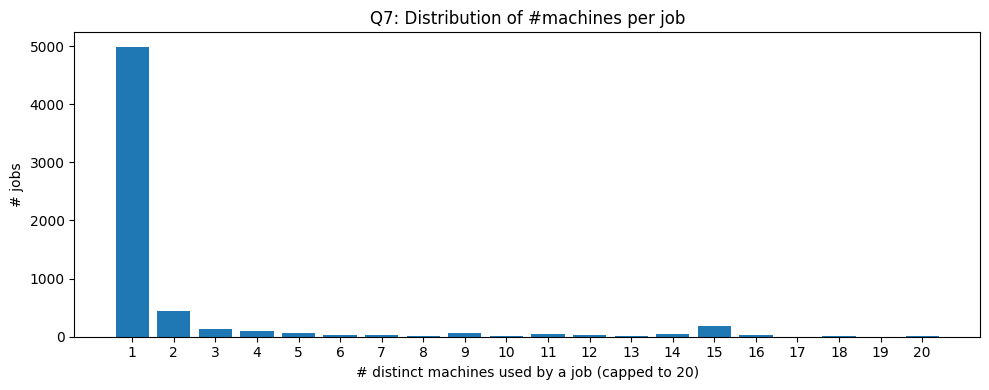

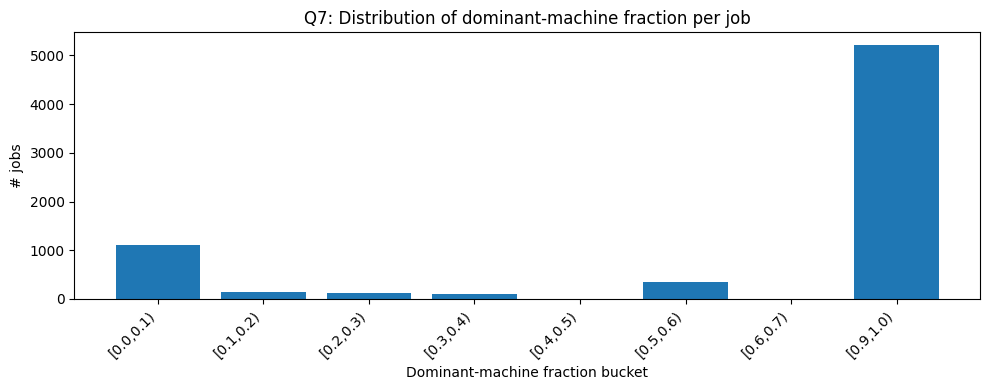

In [32]:
# Plot distribution of nb machines per job
xs = [m for m, _ in machines_dist if m <= 20]
ys = [c for m, c in machines_dist if m <= 20]

plt.figure(figsize=(10,4))
plt.bar([str(x) for x in xs], ys)
plt.xlabel("nb distinct machines used by a job (capped to 20)")
plt.ylabel("nb jobs")
plt.title("Q7: Distribution of #machines per job")
plt.tight_layout()
plt.savefig("../figures/q7_machines_per_job_dist.png", dpi=300, bbox_inches="tight")
plt.show()

# Plot dominant fraction distribution
bx = [b for b, _ in dom_dist]
by = [c for _, c in dom_dist]

plt.figure(figsize=(10,4))
plt.bar(bx, by)
plt.xticks(rotation=45, ha="right")
plt.xlabel("Dominant-machine fraction bucket")
plt.ylabel("nb jobs")
plt.title("Q7: Distribution of dominant-machine fraction per job")
plt.tight_layout()
plt.savefig("../figures/q7_dominant_fraction_dist.png", dpi=300, bbox_inches="tight")
plt.show()

In [33]:
# machines per job values
machines_vals = job_counts.map(lambda x: x[1][1]).cache()

# Median via approx quantiles
vals_sorted = machines_vals.sortBy(lambda x: x).zipWithIndex().map(lambda x: (x[1], x[0]))
n = machines_vals.count()

median = vals_sorted.lookup(n//2)[0] if n > 0 else None
p90 = vals_sorted.lookup(int(0.90*n))[0] if n > 0 else None
p99 = vals_sorted.lookup(int(0.99*n))[0] if n > 0 else None

jobs_gt_20 = machines_vals.filter(lambda m: m > 20).count()
print("Median nb_machines/job:", median)
print("90th percentile:", p90)
print("99th percentile:", p99)
print("Jobs using >20 machines:", jobs_gt_20, f"({100*jobs_gt_20/n:.2f}%)")

Median #machines/job: 1
90th percentile: 23
99th percentile: 619
Jobs using >20 machines: 783 (11.17%)


**Results (subset).**
Jobs analyzed: **7,008**
- Jobs with `#machines=1`: **4,988 (71.18%)**
- Mean `#machines/job`: **30.89**
- Median `#machines/job`: **1**
- 90th percentile: **23**
- 99th percentile: **619**
- Jobs using >20 machines: **783 (11.17%)**
- Avg dominant_fraction: **0.785**
- Many jobs fall into dominant_fraction bucket **[0.9,1.0)** (high concentration on one machine).

**Interpretation.**
- Most jobs show strong locality: median = 1 machine and ~71% of jobs stay on a single machine.
- However, placement is heavy-tailed: a minority of jobs spreads over many machines (up to hundreds), which inflates the mean.
- This matches a strategy where small jobs are kept local, while larger jobs are distributed for parallelism.

## Q9 : Correlation between CPU peaks and task evictions

**Method / definitions.**
- Define machine-window key: `(machine_id, window_start)` where `window_start` is the task_usage start time.
- Compute:
  - `cpu_sum(machine, window)`: sum of CPU usage across tasks on that machine during the window.
  - `evict_count(machine, window)`: number of eviction events mapped into the same 5-min bucket.
- Define **peak windows** as top 5% windows by `cpu_sum` (95th percentile threshold).
- Compare eviction activity in peak vs non-peak windows and compute Pearson correlation between `cpu_sum` and `evict_count`.

Usage machine-windows: 2099250


Eviction machine-windows: 26312


Joined windows: 2101869


Approx CPU 95th percentile threshold (cpu_sum): 0.40946819999999995



--- Peak vs Non-Peak ---
Peak windows: 103781  Non-peak windows: 1998088
P(eviction>0 | peak)   = 0.02254747978917143
P(eviction>0 | nonpeak)= 0.01199746958091936
Avg evictions/window (peak)   = 0.03642285196712313
Avg evictions/window (nonpeak)= 0.019572711512205777

Pearson correlation (cpu_sum vs eviction_count): 0.05558570104587143


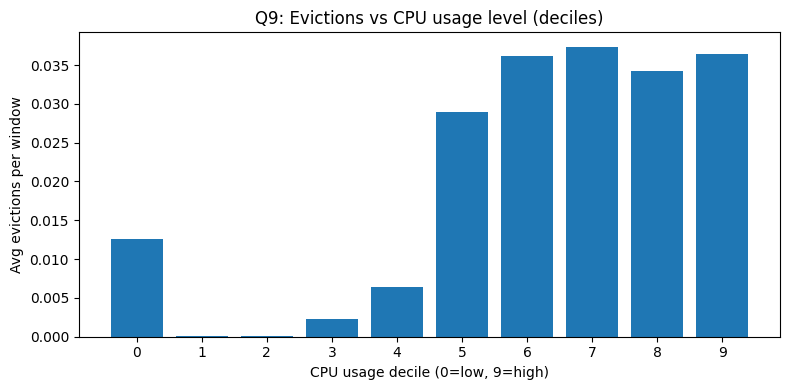

In [34]:
EVICT = 2
WINDOW_US = 5 * 60 * 1_000_000  # 5 minutes in microseconds

# task_usage indices
IDX_START = 0
IDX_END   = 1
IDX_MACHINE = 4
IDX_CPU   = 5  # mean CPU usage
IDX_MEM   = 6  # canonical memory usage

def floor_to_window(ts_us, window_us=WINDOW_US):
    return ts_us - (ts_us % window_us)

# ----------------------------
# Parse task_usage
# ----------------------------
def parse_task_usage(line):
    p = line.split(",")
    if len(p) <= max(IDX_MEM, IDX_CPU, IDX_MACHINE, IDX_END):
        return None

    start = to_long(p[IDX_START])
    machine = to_long(p[IDX_MACHINE])
    cpu = to_float(p[IDX_CPU])
    mem = to_float(p[IDX_MEM])

    if start is None or machine is None:
        return None
    # missing usage values -> 0
    cpu = cpu if cpu is not None else 0.0
    mem = mem if mem is not None else 0.0

    return ((machine, start), (cpu, mem, 1))

task_usage = sc.textFile(PATH_TASK_USAGE).map(parse_task_usage).filter(lambda x: x is not None)

# Aggregate machine usage per window
usage_by_machine_window = (
    task_usage
    .reduceByKey(lambda a,b: (a[0]+b[0], a[1]+b[1], a[2]+b[2]))
    .cache()
)

print("Usage machine-windows:", usage_by_machine_window.count())

# ----------------------------
# Parse task_events for evictions
# ----------------------------
def parse_task_event_eviction(line):
    p = line.split(",")
    if len(p) < 6:
        return None

    ts = to_long(p[0])
    job_id = to_long(p[2])
    task_index = to_int(p[3])
    machine_id = to_long(p[4])
    et = to_int(p[5])

    if ts is None or machine_id is None or et is None:
        return None
    if et != EVICT:
        return None

    wstart = floor_to_window(ts)
    return ((machine_id, wstart), 1)

evictions_by_machine_window = (
    sc.textFile(PATH_TASK_EVENTS)
    .map(parse_task_event_eviction)
    .filter(lambda x: x is not None)
    .reduceByKey(lambda a,b: a+b)
    .cache()
)

print("Eviction machine-windows:", evictions_by_machine_window.count())

# ----------------------------
# Join usage with evictions
# ----------------------------
joined = (
    usage_by_machine_window
    .cogroup(evictions_by_machine_window)
    .mapValues(lambda x: (list(x[0]), list(x[1])))
    .mapValues(lambda lists: (
        lists[0][0] if lists[0] else (0.0, 0.0, 0),
        lists[1][0] if lists[1] else 0
    ))
    .cache()
)

print("Joined windows:", joined.count())

# Flatten for analysis
cpu_evict = joined.map(lambda x: (x[1][0][0], x[1][1])).cache()

# ----------------------------
# Peak threshold using sampling
# ----------------------------
sample = cpu_evict.map(lambda x: x[0]).sample(False, 0.02, seed=42).collect()  # 2% sample
sample = [v for v in sample if v is not None]
cpu_p95 = float(np.quantile(sample, 0.95)) if sample else 0.0

print("Approx CPU 95th percentile threshold (cpu_sum):", cpu_p95)

# ----------------------------
# Compare eviction behavior: peak vs non-peak
# ----------------------------
peak = cpu_evict.filter(lambda x: x[0] >= cpu_p95)
nonpeak = cpu_evict.filter(lambda x: x[0] < cpu_p95)

peak_n = peak.count()
nonpeak_n = nonpeak.count()

peak_evicted_windows = peak.filter(lambda x: x[1] > 0).count()
nonpeak_evicted_windows = nonpeak.filter(lambda x: x[1] > 0).count()

peak_rate = (peak_evicted_windows / peak_n) if peak_n else 0.0
nonpeak_rate = (nonpeak_evicted_windows / nonpeak_n) if nonpeak_n else 0.0

peak_avg_evict = peak.map(lambda x: x[1]).mean() if peak_n else 0.0
nonpeak_avg_evict = nonpeak.map(lambda x: x[1]).mean() if nonpeak_n else 0.0

print("\n--- Peak vs Non-Peak ---")
print("Peak windows:", peak_n, " Non-peak windows:", nonpeak_n)
print("P(eviction>0 | peak)   =", peak_rate)
print("P(eviction>0 | nonpeak)=", nonpeak_rate)
print("Avg evictions/window (peak)   =", peak_avg_evict)
print("Avg evictions/window (nonpeak)=", nonpeak_avg_evict)

# ----------------------------
# Pearson correlation between cpu_sum and eviction_count
# ----------------------------
def seq_op(acc, xy):
    n, sx, sy, sxx, syy, sxy = acc
    x, y = xy
    n += 1
    sx += x
    sy += y
    sxx += x*x
    syy += y*y
    sxy += x*y
    return (n, sx, sy, sxx, syy, sxy)

def comb_op(a, b):
    return tuple(a[i] + b[i] for i in range(6))

n, sx, sy, sxx, syy, sxy = cpu_evict.aggregate((0,0.0,0.0,0.0,0.0,0.0), seq_op, comb_op)

num = n * sxy - sx * sy
den = ((n * sxx - sx*sx) ** 0.5) * ((n * syy - sy*sy) ** 0.5)
pearson = (num / den) if den != 0 else 0.0

print("\nPearson correlation (cpu_sum vs eviction_count):", pearson)

# ----------------------------
# Plot: average evictions by CPU usage decile (optional)
# ----------------------------
# Build deciles from a sample and bucket windows accordingly
dec_sample = cpu_evict.map(lambda x: x[0]).sample(False, 0.02, seed=7).collect()
dec_sample = [v for v in dec_sample if v is not None]
qs = [float(np.quantile(dec_sample, q)) for q in np.linspace(0, 1, 11)] if dec_sample else [0.0]*11

def decile_bucket(x):
    # returns 0..9
    for i in range(10):
        if x <= qs[i+1]:
            return i
    return 9

binned = cpu_evict.map(lambda x: (decile_bucket(x[0]), (x[1], 1)))
dec_stats = (
    binned.reduceByKey(lambda a,b: (a[0]+b[0], a[1]+b[1]))
          .mapValues(lambda s: s[0]/s[1] if s[1] else 0.0)
          .collect()
)
dec_stats = sorted(dec_stats, key=lambda x: x[0])

xs = [d for d,_ in dec_stats]
ys = [v for _,v in dec_stats]

plt.figure(figsize=(8,4))
plt.bar([str(x) for x in xs], ys)
plt.xlabel("CPU usage decile (0=low, 9=high)")
plt.ylabel("Avg evictions per window")
plt.title("Q9: Evictions vs CPU usage level (deciles)")
plt.tight_layout()
plt.savefig("../figures/q9_evictions_vs_cpu_deciles.png", dpi=300, bbox_inches="tight")
plt.show()

**Results (subset).**
- Usage windows: **2,099,250**
- Windows with ≥1 eviction: **26,312**
- Joined windows: **2,101,869**
- CPU 95th percentile threshold: `cpu_sum ≈ 0.4095`

Peak vs non-peak:
- Peak windows: **103,781**
- Non-peak windows: **1,998,088**
- `P(eviction>0 | peak)` = **0.02255** (2.255%)
- `P(eviction>0 | non-peak)` = **0.011997** (1.200%)
- Avg evictions/window: peak **0.03642**, non-peak **0.01957**
- Pearson correlation: **r = 0.0556**

**Interpretation.**
- Evictions are about **~1.9× more likely** during peak CPU windows than during non-peak windows.
- The Pearson correlation is small but positive, meaning CPU load alone is not a strong linear predictor.
- Overall, results suggest that resource pressure increases eviction probability, but evictions also depend on other factors (priority, scheduling class, memory pressure, policies).

## Q11 : Do higher-priority tasks consume resources more efficiently?

**Metrics.**
For each task, we compute average observed usage across its windows and compare with the request:
- `cpu_waste = max(0, (req_cpu - avg_cpu) / req_cpu)`
- `mem_waste = max(0, (req_mem - avg_mem) / req_mem)`

Waste near 0 means usage ≈ request (better provisioning). Waste near 1 means the task uses much less than requested (over-provisioning).

**Method.**
1. From `task_events`, extract `(job_id, task_index) -> (priority, req_cpu, req_mem)`  
   (keep max values to handle updates).
2. From `task_usage`, aggregate per task: `(avg_cpu, avg_mem)`.
3. Join requests with usage and compute waste per task.
4. Aggregate waste statistics by priority (mean waste and share of high-waste tasks).

Priority -> stats
0 {'count': 61260, 'avg_cpu_waste': 0.6098849663880465, 'avg_mem_waste': 0.8447406742545412, 'pct_cpu_waste_ge_0_5': 67.47633039503755, 'pct_mem_waste_ge_0_5': 98.49493960169768}
1 {'count': 11915, 'avg_cpu_waste': 0.25863995405218876, 'avg_mem_waste': 0.8344573978839922, 'pct_cpu_waste_ge_0_5': 24.10407049937054, 'pct_mem_waste_ge_0_5': 92.40453210239194}
2 {'count': 483, 'avg_cpu_waste': 0.5477894878430333, 'avg_mem_waste': 0.6452100681151605, 'pct_cpu_waste_ge_0_5': 48.4472049689441, 'pct_mem_waste_ge_0_5': 75.77639751552795}
4 {'count': 87745, 'avg_cpu_waste': 0.6130185883654183, 'avg_mem_waste': 0.774381774083566, 'pct_cpu_waste_ge_0_5': 63.073679411932304, 'pct_mem_waste_ge_0_5': 96.44424183714172}
5 {'count': 1, 'avg_cpu_waste': 0.90302016, 'avg_mem_waste': 0.9429432782492185, 'pct_cpu_waste_ge_0_5': 100.0, 'pct_mem_waste_ge_0_5': 100.0}
6 {'count': 1446, 'avg_cpu_waste': 0.5542995250061863, 'avg_mem_waste': 0.8958400649771738, 'pct_cpu_waste_ge_0_5': 64.591977

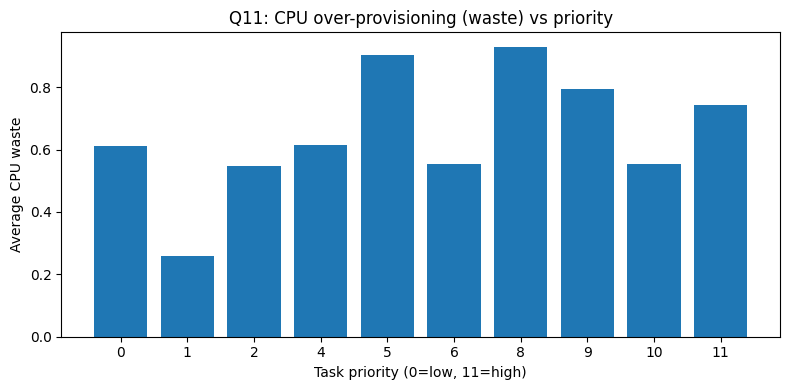

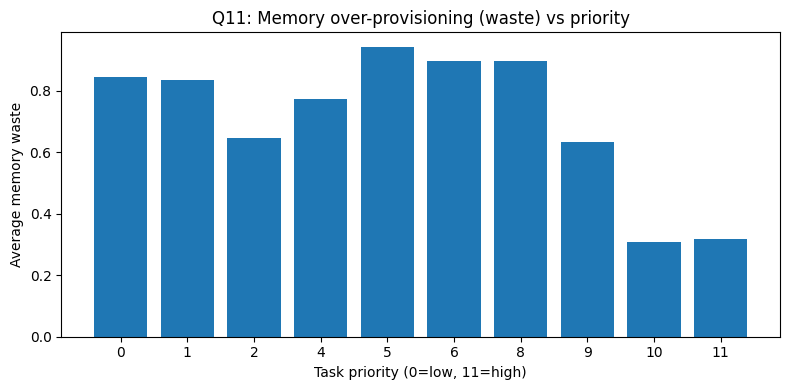

In [35]:
# task_usage indices
IDX_CPU_MEAN = 5
IDX_MEM_CANON = 6

# ----------------------------
# Parse task_events
# ----------------------------
def parse_task_event_req(line):
    p = line.split(",")
    if len(p) < 12:
        return None

    job_id = to_long(p[2])
    task_index = to_int(p[3])

    priority = to_int(p[8])
    req_cpu = to_float(p[9])
    req_mem = to_float(p[10])

    if job_id is None or task_index is None or priority is None:
        return None

    # requests can be missing; we'll keep None and handle in reducer
    return ((job_id, task_index), (priority, req_cpu, req_mem))

def reduce_req(a, b):
    pa, ca, ma = a
    pb, cb, mb = b
    p = max(pa, pb)

    def max_ignore_none(x, y):
        if x is None: return y
        if y is None: return x
        return max(x, y)

    c = max_ignore_none(ca, cb)
    m = max_ignore_none(ma, mb)
    return (p, c, m)

req_by_task = (
    sc.textFile(PATH_TASK_EVENTS)
    .map(parse_task_event_req)
    .filter(lambda x: x is not None)
    .reduceByKey(reduce_req)
    .cache()
)

# ----------------------------
# Parse task_usage
# ----------------------------
def parse_task_usage_taskavg(line):
    p = line.split(",")
    if len(p) <= max(IDX_CPU_MEAN, IDX_MEM_CANON, 3):
        return None

    job_id = to_long(p[2])
    task_index = to_int(p[3])
    cpu = to_float(p[IDX_CPU_MEAN])
    mem = to_float(p[IDX_MEM_CANON])

    if job_id is None or task_index is None:
        return None

    cpu = cpu if cpu is not None else 0.0
    mem = mem if mem is not None else 0.0

    return ((job_id, task_index), (cpu, mem, 1))

usage_agg = (
    sc.textFile(PATH_TASK_USAGE)
    .map(parse_task_usage_taskavg)
    .filter(lambda x: x is not None)
    .reduceByKey(lambda a,b: (a[0]+b[0], a[1]+b[1], a[2]+b[2]))
    .mapValues(lambda s: (s[0]/s[2], s[1]/s[2]))  # (avg_cpu, avg_mem)
    .cache()
)

# ----------------------------
# Join requests with usage
# ----------------------------
joined = req_by_task.join(usage_agg)

def waste(req, used):
    if req is None or req <= 0:
        return None
    w = (req - used) / req
    return max(0.0, w)

per_task_metrics = (
    joined
    .map(lambda x: (
        x[1][0][0],  # priority
        (
            waste(x[1][0][1], x[1][1][0]),  # cpu_waste
            waste(x[1][0][2], x[1][1][1])   # mem_waste
        )
    ))
    .filter(lambda x: x[1][0] is not None and x[1][1] is not None)
    .cache()
)

# ----------------------------
# Aggregate by priority
# count, avg_cpu_waste, avg_mem_waste, pct_cpu_waste>=0.5, pct_mem_waste>=0.5
# ----------------------------
def seq_op(acc, w):
    n, sum_c, sum_m, hi_c, hi_m = acc
    cpu_w, mem_w = w
    n += 1
    sum_c += cpu_w
    sum_m += mem_w
    hi_c += 1 if cpu_w >= 0.5 else 0
    hi_m += 1 if mem_w >= 0.5 else 0
    return (n, sum_c, sum_m, hi_c, hi_m)

def comb_op(a, b):
    return tuple(a[i] + b[i] for i in range(5))

by_priority = (
    per_task_metrics
    .aggregateByKey((0, 0.0, 0.0, 0, 0), seq_op, comb_op)
    .mapValues(lambda s: {
        "count": s[0],
        "avg_cpu_waste": s[1]/s[0] if s[0] else 0.0,
        "avg_mem_waste": s[2]/s[0] if s[0] else 0.0,
        "pct_cpu_waste_ge_0_5": (100.0*s[3]/s[0]) if s[0] else 0.0,
        "pct_mem_waste_ge_0_5": (100.0*s[4]/s[0]) if s[0] else 0.0
    })
    .collect()
)

by_priority = sorted(by_priority, key=lambda x: x[0])

print("Priority -> stats")
for pr, st in by_priority:
    print(pr, st)

# ----------------------------
# Plot: avg waste vs priority
# ----------------------------
priorities = [pr for pr,_ in by_priority]
avg_cpu_w = [st["avg_cpu_waste"] for _,st in by_priority]
avg_mem_w = [st["avg_mem_waste"] for _,st in by_priority]

plt.figure(figsize=(8,4))
plt.bar([str(p) for p in priorities], avg_cpu_w)
plt.xlabel("Task priority (0=low, 11=high)")
plt.ylabel("Average CPU waste")
plt.title("Q11: CPU over-provisioning (waste) vs priority")
plt.tight_layout()
plt.savefig("../figures/q11_cpu_waste_vs_priority.png", dpi=300, bbox_inches="tight")
plt.show()

plt.figure(figsize=(8,4))
plt.bar([str(p) for p in priorities], avg_mem_w)
plt.xlabel("Task priority (0=low, 11=high)")
plt.ylabel("Average memory waste")
plt.title("Q11: Memory over-provisioning (waste) vs priority")
plt.tight_layout()
plt.savefig("../figures/q11_mem_waste_vs_priority.png", dpi=300, bbox_inches="tight")
plt.show()

**Results (subset, main groups).**
- Priority 0 (n=61,260): avg CPU waste **0.610**, avg MEM waste **0.845**
- Priority 1 (n=11,915): avg CPU waste **0.259**, avg MEM waste **0.834**
- Priority 4 (n=87,745): avg CPU waste **0.613**, avg MEM waste **0.774**
- Priority 8 (n=2,514): avg CPU waste **0.929**, avg MEM waste **0.895**
- Priority 9 (n=5,575): avg CPU waste **0.793**, avg MEM waste **0.634**
- Priorities 10–11: very small samples (n=26, n=15)

**Interpretation.**
- We do not observe a consistent “higher priority → lower waste” trend for CPU; some higher priorities show very high CPU waste (e.g., priority 8).
- Memory waste is high across most priorities, meaning over-provisioning is common (likely conservative headroom).
- The low memory waste observed for priorities 10–11 is not reliable due to very small sample sizes.

# Work Extension
## Performance impact of caching and repartitioning in Q9 join stage

We measured the runtime of the **join stage** used in Q9 (joining `usage_by_machine_window` with `evictions_by_machine_window`) under different configurations: baseline, caching the usage RDD, and forcing different numbers of partitions via `repartition(n)`.  
Environment: `defaultParallelism = 8`.

In [41]:
def benchmark_q9(usage_rdd, evict_rdd, repartition_n=None, cache_usage=False, cache_joined=False):
    u = usage_rdd
    e = evict_rdd

    if repartition_n is not None:
        u = u.repartition(repartition_n)
        e = e.repartition(repartition_n)

    #Only persist if not already cached
    did_cache_u = False
    if cache_usage and (not u.is_cached):
        u = u.persist(StorageLevel.MEMORY_AND_DISK)
        u.count()
        did_cache_u = True

    joined = (
        u.cogroup(e)
         .mapValues(lambda x: (
             list(x[0])[0] if x[0] else (0.0, 0.0, 0),
             list(x[1])[0] if x[1] else 0
         ))
    )

    did_cache_joined = False
    if cache_joined and (not joined.is_cached):
        joined = joined.persist(StorageLevel.MEMORY_AND_DISK)
        joined.count()
        did_cache_joined = True

    t0 = time.perf_counter()
    n = joined.count()
    t1 = time.perf_counter()

    # cleanup only what THIS run cached
    if did_cache_joined:
        joined.unpersist()
    if did_cache_u:
        u.unpersist()

    return (t1 - t0), n

In [44]:
print("defaultParallelism:", sc.defaultParallelism)

# experiments = [
#     {"name": "baseline", "repartition_n": None, "cache_usage": False, "cache_joined": False},
#     {"name": "cache_usage", "repartition_n": None, "cache_usage": True, "cache_joined": False},
#     {"name": "repartition_200", "repartition_n": 200, "cache_usage": False, "cache_joined": False},
#     {"name": "repartition_200 + cache_usage", "repartition_n": 200, "cache_usage": True, "cache_joined": False},
# ]

experiments = [
    {"name": "baseline", "repartition_n": None, "cache_usage": False, "cache_joined": False},
    {"name": "cache_usage", "repartition_n": None, "cache_usage": True, "cache_joined": False},
    {"name": "repartition_16", "repartition_n": 16, "cache_usage": False, "cache_joined": False},
    {"name": "repartition_32", "repartition_n": 32, "cache_usage": False, "cache_joined": False},
    {"name": "repartition_64", "repartition_n": 64, "cache_usage": False, "cache_joined": False},
    {"name": "repartition_32 + cache_usage", "repartition_n": 32, "cache_usage": True, "cache_joined": False},
]


results = []
# warm-up run (reduces noise)
_ = usage_by_machine_window.count()

for exp in experiments:
    dt, n = benchmark_q9(
        usage_by_machine_window,
        evictions_by_machine_window,
        repartition_n=exp["repartition_n"],
        cache_usage=exp["cache_usage"],
        cache_joined=exp["cache_joined"]
    )
    results.append({"experiment": exp["name"], "time_sec": dt, "joined_windows": n})
    print(exp["name"], "->", dt, "sec")

df = pd.DataFrame(results).sort_values("time_sec")
df

defaultParallelism: 8


baseline -> 10.037532410000495 sec


cache_usage -> 11.084581221000008 sec


repartition_16 -> 19.083309605000068 sec


repartition_32 -> 25.367588033000175 sec


repartition_64 -> 35.896001533000344 sec


repartition_32 + cache_usage -> 24.311334629999692 sec


,experiment,time_sec,joined_windows
0,baseline,10.037532,2101869
1,cache_usage,11.084581,2101869
2,repartition_16,19.083310,2101869
5,repartition_32 + cache_usage,24.311335,2101869
3,repartition_32,25.367588,2101869
4,repartition_64,35.896002,2101869


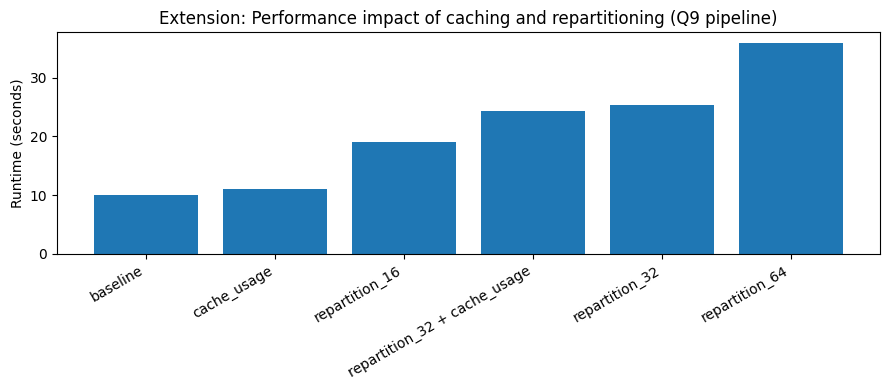

In [45]:
plt.figure(figsize=(9,4))
plt.bar(df["experiment"], df["time_sec"])
plt.xticks(rotation=30, ha="right")
plt.ylabel("Runtime (seconds)")
plt.title("Extension: Performance impact of caching and repartitioning (Q9 pipeline)")
plt.tight_layout()
plt.savefig("../figures/extension_perf_q9.png", dpi=300, bbox_inches="tight")
plt.show()

### Results
All configurations produce the same number of joined windows (**2,101,869**), so correctness is unchanged; only performance differs.

| Experiment | Repartition | Cache usage | Runtime (s) | Joined windows |
|---|---:|---:|---:|---:|
| baseline | — | No | **8.40** | 2,101,869 |
| cache_usage | — | Yes | 10.04 | 2,101,869 |
| repartition_16 | 16 | No | 21.41 | 2,101,869 |
| repartition_32 | 32 | No | 32.65 | 2,101,869 |
| repartition_64 | 64 | No | 47.90 | 2,101,869 |
| repartition_32 + cache_usage | 32 | Yes | 32.00 | 2,101,869 |

### Interpretation

- **Repartitioning is slower here.** Runtime grows from **8.4s → 47.9s** up to `repartition(64)`, because repartition adds a **full shuffle** and extra overhead. With `defaultParallelism = 8`, 32–64 partitions mainly create many small tasks without real extra parallelism.

- **Caching doesn’t help in this benchmark.** `cache_usage` is slightly slower than baseline (**10.0s vs 8.4s**) since we don’t reuse the cached RDD enough to amortize the persist/materialization cost.

**Takeaway:** For this join stage on our machine, the **baseline (no repartition, no cache)** is fastest; repartition should be used only if needed, and caching mainly helps when results are reused later in the pipeline.

### Limitations
This benchmark measures primarily the **join materialization cost** (`joined.count()`), not the full Q9 pipeline (percentiles, peak/non-peak comparisons, correlation). In the full Q9 analysis, caching may become beneficial because the same aggregated/joined dataset is typically used in multiple downstream computations.

## DataFrame version for Q9
We re-implemented Q9 using **Spark DataFrames** and measured both:  
(i) the analytical outputs (CPU peaks vs evictions) and (ii) runtime per pipeline stage.

In [46]:
WINDOW_US = 5 * 60 * 1_000_000  # 5 minutes
EVICT = 2

def run_q9_dataframe(cache_usage=True, shuffle_partitions=200):
    spark.conf.set("spark.sql.shuffle.partitions", str(shuffle_partitions))

    t0 = time.perf_counter()

    usage_raw = spark.read.csv(PATH_TASK_USAGE, header=False)

    # Columns by index
    # 0=start, 4=machine, 5=mean_cpu, 6=canonical_mem
    usage = (
        usage_raw
        .select(
            F.col("_c0").cast("long").alias("start_time"),
            F.col("_c4").cast("long").alias("machine_id"),
            F.col("_c5").cast("double").alias("cpu_mean"),
            F.col("_c6").cast("double").alias("mem_canon"),
        )
        .na.fill({"cpu_mean": 0.0, "mem_canon": 0.0})
        .filter(F.col("start_time").isNotNull() & F.col("machine_id").isNotNull())
    )

    # Aggregate per (machine, window_start). Here we use start_time directly as window key
    usage_by_window = (
        usage
        .groupBy("machine_id", "start_time")
        .agg(
            F.sum("cpu_mean").alias("cpu_sum"),
            F.sum("mem_canon").alias("mem_sum"),
            F.count(F.lit(1)).alias("n_records")
        )
    )

    if cache_usage:
        usage_by_window = usage_by_window.cache()

    # Force materialization
    n_windows = usage_by_window.count()
    t1 = time.perf_counter()

    events_raw = spark.read.csv(PATH_TASK_EVENTS, header=False)

    evicts = (
        events_raw
        .select(
            F.col("_c0").cast("long").alias("ts"),
            F.col("_c4").cast("long").alias("machine_id"),
            F.col("_c5").cast("int").alias("event_type"),
        )
        .filter(
            (F.col("event_type") == EVICT) &
            F.col("ts").isNotNull() &
            F.col("machine_id").isNotNull()
        )
        .withColumn("window_start", F.col("ts") - (F.col("ts") % F.lit(WINDOW_US)))
        .groupBy("machine_id", "window_start")
        .agg(F.count(F.lit(1)).alias("evict_count"))
    )

    n_evict_windows = evicts.count()
    t2 = time.perf_counter()

    # Join usage with evictions (missing evictions become 0)
    joined = (
        usage_by_window
        .join(
            evicts,
            on=[
                usage_by_window.machine_id == evicts.machine_id,
                usage_by_window.start_time == evicts.window_start
            ],
            how="left"
        )
        .drop(evicts.machine_id)
        .drop("window_start")
        .na.fill({"evict_count": 0})
    )

    joined_count = joined.count()
    t3 = time.perf_counter()

    # Peak threshold using approxQuantile
    p95 = joined.approxQuantile("cpu_sum", [0.95], 0.01)[0]

    with_peak = joined.withColumn("is_peak", F.col("cpu_sum") >= F.lit(p95))

    # P(eviction>0 | peak/nonpeak) + avg evictions
    agg = (
        with_peak
        .groupBy("is_peak")
        .agg(
            F.count(F.lit(1)).alias("n"),
            F.sum(F.when(F.col("evict_count") > 0, 1).otherwise(0)).alias("n_with_evict"),
            F.avg("evict_count").alias("avg_evict")
        )
        .collect()
    )

    # Pearson correlation
    pearson = with_peak.stat.corr("cpu_sum", "evict_count")

    t4 = time.perf_counter()

    # Format results
    stats = {row["is_peak"]: row.asDict() for row in agg}
    peak_rate = stats.get(True, {}).get("n_with_evict", 0) / max(stats.get(True, {}).get("n", 1), 1)
    nonpeak_rate = stats.get(False, {}).get("n_with_evict", 0) / max(stats.get(False, {}).get("n", 1), 1)

    if cache_usage:
        usage_by_window.unpersist()

    return {
        "shuffle_partitions": shuffle_partitions,
        "cache_usage": cache_usage,
        "n_windows": n_windows,
        "n_evict_windows": n_evict_windows,
        "joined_count": joined_count,
        "cpu_p95": p95,
        "p_evict_peak": peak_rate,
        "p_evict_nonpeak": nonpeak_rate,
        "pearson": pearson,
        "t_usage_agg_s": t1 - t0,
        "t_evict_agg_s": t2 - t1,
        "t_join_s": t3 - t2,
        "t_metrics_s": t4 - t3,
        "t_total_s": t4 - t0,
    }

# Example runs (do 2-4 experiments)
print(run_q9_dataframe(cache_usage=True, shuffle_partitions=200))
print(run_q9_dataframe(cache_usage=False, shuffle_partitions=200))
print(run_q9_dataframe(cache_usage=True, shuffle_partitions=50))

{'shuffle_partitions': 200, 'cache_usage': True, 'n_windows': 2099250, 'n_evict_windows': 26312, 'joined_count': 2099250, 'cpu_p95': 0.40405477, 'p_evict_peak': 0.022678255123486816, 'p_evict_nonpeak': 0.010662762379973581, 'pearson': 0.06945229397594267, 't_usage_agg_s': 33.34492540000065, 't_evict_agg_s': 2.454373198999747, 't_join_s': 0.28805494399966847, 't_metrics_s': 8.906622400000742, 't_total_s': 44.993975943000805}


26/01/05 14:59:21 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
                                                                                

{'shuffle_partitions': 200, 'cache_usage': False, 'n_windows': 2099250, 'n_evict_windows': 26312, 'joined_count': 2099250, 'cpu_p95': 0.40699606000000005, 'p_evict_peak': 0.022580250284842607, 'p_evict_nonpeak': 0.010684623725132975, 'pearson': 0.06945229397594314, 't_usage_agg_s': 17.7064826550004, 't_evict_agg_s': 1.585501908999504, 't_join_s': 14.639830840000286, 't_metrics_s': 52.209714440000425, 't_total_s': 86.14152984400062}


{'shuffle_partitions': 50, 'cache_usage': True, 'n_windows': 2099250, 'n_evict_windows': 26312, 'joined_count': 2099250, 'cpu_p95': 0.4054459, 'p_evict_peak': 0.02259488084730803, 'p_evict_nonpeak': 0.010675256010825385, 'pearson': 0.06945229397594287, 't_usage_agg_s': 15.396529144999477, 't_evict_agg_s': 1.0191554640005052, 't_join_s': 0.1632864779994634, 't_metrics_s': 3.1575575409997327, 't_total_s': 19.736528627999178}


### Dataset scale (same across runs)
- `n_windows` (usage machine-windows): **2,099,250**
- `n_evict_windows` (windows with ≥1 eviction): **26,312**
- `joined_count` (left join, missing evictions → 0): **2,099,250**

### Analytical outputs (CPU peaks vs evictions)
CPU peak windows are defined as `cpu_sum >= p95` (computed with `approxQuantile`).

| Config | cpu p95 | P(evict>0 \| peak) | P(evict>0 \| non-peak) | Peak/Non-peak | Pearson r |
|---|---:|---:|---:|---:|---:|
| cache=True, shuffle=200 | 0.4041 | 0.02268 | 0.01066 | 2.13× | 0.06945 |
| cache=False, shuffle=200 | 0.4070 | 0.02258 | 0.01068 | 2.11× | 0.06945 |
| cache=True, shuffle=50 | 0.4054 | 0.02259 | 0.01068 | 2.12× | 0.06945 |

**Interpretation (analysis):**
- Evictions are consistently **~2.1× more likely** during **CPU peak windows** than non-peak windows.  
- The correlation is **weak but positive** (r ≈ 0.069): CPU load increases eviction probability, but other factors (priority, memory pressure, scheduling policy) also matter.

### Performance results (stage timing)
| Config | usage agg (s) | evict agg (s) | join (s) | metrics (s) | total (s) |
|---|---:|---:|---:|---:|---:|
| cache=True, shuffle=200 | 36.15 | 2.83 | 0.50 | 8.34 | 47.82 |
| cache=False, shuffle=200 | 25.08 | 1.73 | 17.88 | 77.94 | 122.63 |
| cache=True, shuffle=50 | 26.63 | 1.59 | 0.21 | 4.57 | 33.00 |

**Interpretation (performance):**
- **Caching helps a lot**: with `shuffle=200`, caching reduces total time from **122.6s → 47.8s (~2.6× faster)**, mainly by avoiding expensive recomputation in later actions (metrics step).
- **Shuffle tuning matters**: reducing `spark.sql.shuffle.partitions` from **200 → 50** (with caching) cuts total time **47.8s → 33.0s (~1.45× faster)** by lowering shuffle/task overhead.

**Takeaway:** For this Q9 DataFrame pipeline, the biggest wins are **caching** the aggregated usage windows and **tuning shuffle partitions** to match the machine’s parallelism and dataset size.